In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, fcluster
import os
from PIL import Image
import torch
from transformers import TrOCRProcessor, VisionEncoderDecoderModel

In [2]:
def detect_text_components(image_path, debug=False):
    """
    Detect individual text components (connected components) for OCR processing
    """
    # Load image
    image = cv2.imread(image_path)
    if image is None:
        raise ValueError(f"Could not load image at {image_path}")
    
    # Create a copy for visualization
    output = image.copy()
    
    # Convert to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    
    # Apply Gaussian blur
    blur = cv2.GaussianBlur(gray, (5, 5), 0)
    
    # Apply Otsu's thresholding
    _, thresh = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    
    # Find all connected components (white patches)
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(thresh, connectivity=8)
    
    # Skip the first component (background)
    component_stats = []
    for i in range(1, num_labels):
        x, y, w, h, area = stats[i]
        
        # Filter out very small components that might be noise
        if w > 3 and h > 3 and area > 10:
            component_stats.append((x, y, w, h, area))
    
    # Sort components by x-coordinate (left to right)
    component_stats.sort(key=lambda x: x[0])
    
    # Draw bounding boxes around individual components
    for i, (x, y, w, h, area) in enumerate(component_stats):
        cv2.rectangle(output, (x, y), (x+w, y+h), (0, 0, 255), 1)  # Red for individual components
    
    # Group components based on spatial proximity
    if component_stats:
        # Extract centroids of all components
        centroids = [(x + w/2, y + h/2) for x, y, w, h, _ in component_stats]
        
        # Convert to numpy array for clustering
        centroids_array = np.array(centroids)
        
        # Perform hierarchical clustering based on vertical position (y-coordinate)
        y_coords = centroids_array[:, 1].reshape(-1, 1)  # Extract y-coordinates
        
        # Calculate appropriate threshold based on typical text height
        heights = [h for _, _, _, h, _ in component_stats]
        median_height = np.median(heights)
        cluster_threshold = median_height * 0.8  # Adjust as needed
        
        # Perform clustering
        Z = linkage(y_coords, 'ward')
        clusters = fcluster(Z, cluster_threshold, criterion='distance')
        
        # Group components by cluster
        clustered_components = {}
        for i, cluster_id in enumerate(clusters):
            if cluster_id not in clustered_components:
                clustered_components[cluster_id] = []
            clustered_components[cluster_id].append(component_stats[i])
        
        # Sort clusters by vertical position (top to bottom)
        cluster_y_means = {}
        for cluster_id, components in clustered_components.items():
            y_values = [y for _, y, _, _, _ in components]
            cluster_y_means[cluster_id] = np.mean(y_values)
        
        sorted_clusters = sorted(clustered_components.keys(), key=lambda k: cluster_y_means[k])
        
        # Create bounding boxes for each cluster (text line)
        text_lines = []
        for cluster_id in sorted_clusters:
            components = clustered_components[cluster_id]
            
            # Sort components within this cluster by x-coordinate (left to right)
            components.sort(key=lambda c: c[0])
            
            # Calculate the bounding box that encompasses all components in this cluster
            min_x = min(x for x, _, _, _, _ in components)
            min_y = min(y for _, y, _, _, _ in components)
            max_x = max(x + w for x, _, w, _, _ in components)
            max_y = max(y + h for _, y, _, h, _ in components)
            
            text_lines.append((min_x, min_y, max_x - min_x, max_y - min_y))
        
        # Draw text line bounding boxes
        for i, (x, y, w, h) in enumerate(text_lines):
            cv2.rectangle(output, (x, y), (x+w, y+h), (0, 255, 0), 2)  # Green for text lines
            cv2.putText(output, f"Line {i+1}", (x, y-5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)
    else:
        text_lines = []
    
    if debug:
        # Create figure for visualization
        fig, axes = plt.subplots(1, 3, figsize=(18, 6))
        
        # Original image
        axes[0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
        axes[0].set_title('Original Image')
        axes[0].axis('off')
        
        # Thresholded image
        axes[1].imshow(thresh, cmap='gray')
        axes[1].set_title('Thresholded Image')
        axes[1].axis('off')
        
        # Detected components and lines
        axes[2].imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
        axes[2].set_title(f'Detected Components and Lines ({len(text_lines)} lines)')
        axes[2].axis('off')
        
        plt.tight_layout()
        plt.show()
        
        print(f"Detected {len(component_stats)} individual text components")
        print(f"Grouped into {len(text_lines)} text lines")
        
    return output, text_lines, component_stats

In [3]:
def extract_text_regions(image_path, text_regions, output_dir=None, debug=False):
    """
    Extract text regions from the image for OCR processing
    """
    # Load image
    image = cv2.imread(image_path)
    if image is None:
        raise ValueError(f"Could not load image at {image_path}")
    
    # Create output directory if specified
    if output_dir and not os.path.exists(output_dir):
        os.makedirs(output_dir)
    
    # Extract each text region
    extracted_images = []
    for i, (x, y, w, h) in enumerate(text_regions):
        # Add small padding around the region
        pad = 5
        x1 = max(0, x - pad)
        y1 = max(0, y - pad)
        x2 = min(image.shape[1], x + w + pad)
        y2 = min(image.shape[0], y + h + pad)
        
        # Extract the region
        region_img = image[y1:y2, x1:x2]
        extracted_images.append((f"region_{i+1}", region_img))
        
        # Save to file if output directory is specified
        if output_dir:
            output_path = os.path.join(output_dir, f"region_{i+1}.png")
            cv2.imwrite(output_path, region_img)
        
        if debug:
            plt.figure(figsize=(10, 2))
            plt.imshow(cv2.cvtColor(region_img, cv2.COLOR_BGR2RGB))
            plt.title(f"Text Region {i+1}")
            plt.axis('off')
            plt.tight_layout()
            plt.show()
    
    return extracted_images

In [4]:
def prepare_for_trocr(image_path, text_regions, output_dir=None):
    """
    Prepare images for Microsoft TrOCR model
    """
    # Extract regions
    extracted_regions = extract_text_regions(image_path, text_regions, output_dir)
    
    # Convert to PIL Images (required by TrOCR)
    pil_images = []
    for name, img in extracted_regions:
        # Convert from BGR to RGB
        rgb_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        pil_img = Image.fromarray(rgb_img)
        pil_images.append((name, pil_img))
    
    return pil_images

In [5]:
def process_with_trocr(pil_images, model_name='qantev/trocr-large-spanish', batch_size=4, device=None):
    """
    Process images with Microsoft TrOCR model (Spanish version)
    
    Args:
        pil_images: List of tuples (name, PIL.Image)
        model_name: Pretrained TrOCR model name
        batch_size: Number of images to process in one batch
        device: Torch device (None for auto-detection)
    
    Returns:
        List of tuples (name, recognized_text)
    """
    # Auto-detect device if not specified
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    print(f"Loading TrOCR model '{model_name}' on {device}...")
    
    # Load processor and model
    try:
        processor = TrOCRProcessor.from_pretrained(model_name)
        model = VisionEncoderDecoderModel.from_pretrained(model_name).to(device)
    except Exception as e:
        print(f"Error loading model: {e}")
        return [(name, f"Error: {e}") for name, _ in pil_images]
    
    results = []
    
    # Process images in batches
    for i in range(0, len(pil_images), batch_size):
        batch = pil_images[i:i+batch_size]
        names = [item[0] for item in batch]
        images = [item[1] for item in batch]
        
        try:
            # Prepare inputs
            pixel_values = processor(images=images, return_tensors="pt").pixel_values.to(device)
            
            # Generate output
            with torch.no_grad():
                generated_ids = model.generate(pixel_values)
            
            # Decode output
            generated_texts = processor.batch_decode(generated_ids, skip_special_tokens=True)
            
            # Store results
            for name, text in zip(names, generated_texts):
                results.append((name, text))
                print(f"OCR result for {name}: {text}")
        
        except Exception as e:
            print(f"Error processing batch {i//batch_size + 1}: {e}")
            # Add error result for each image in the batch
            for name in names:
                results.append((name, f"Error: {e}"))
    
    return results

In [6]:
def run_complete_ocr_pipeline(image_path, output_dir=None, debug=False, model_name='qantev/trocr-large-spanish', batch_size=4):
    """
    Complete OCR pipeline from image to recognized text
    """
    # 1. Detect text components and lines
    print(f"Detecting text regions in {image_path}...")
    result_image, text_lines, components = detect_text_components(image_path, debug=debug)
    
    # 2. Prepare images for TrOCR
    print(f"Preparing {len(text_lines)} text regions for OCR...")
    pil_images = prepare_for_trocr(image_path, text_lines, output_dir)
    
    # 3. Process with TrOCR
    print("Processing with TrOCR model...")
    ocr_results = process_with_trocr(pil_images, model_name=model_name, batch_size=batch_size)
    
    # 4. Combine results into a single text document
    combined_text = ""
    for name, text in ocr_results:
        combined_text += text + "\n"
    
    # 5. Save combined text if output directory is specified
    if output_dir:
        output_path = os.path.join(output_dir, "recognized_text.txt")
        with open(output_path, 'w', encoding='utf-8') as f:
            f.write(combined_text)
        print(f"Combined OCR text saved to {output_path}")
    
    return result_image, ocr_results, combined_text

Detecting text regions in C:\Users\prana\Downloads\Screenshot 2025-04-01 210010.png...


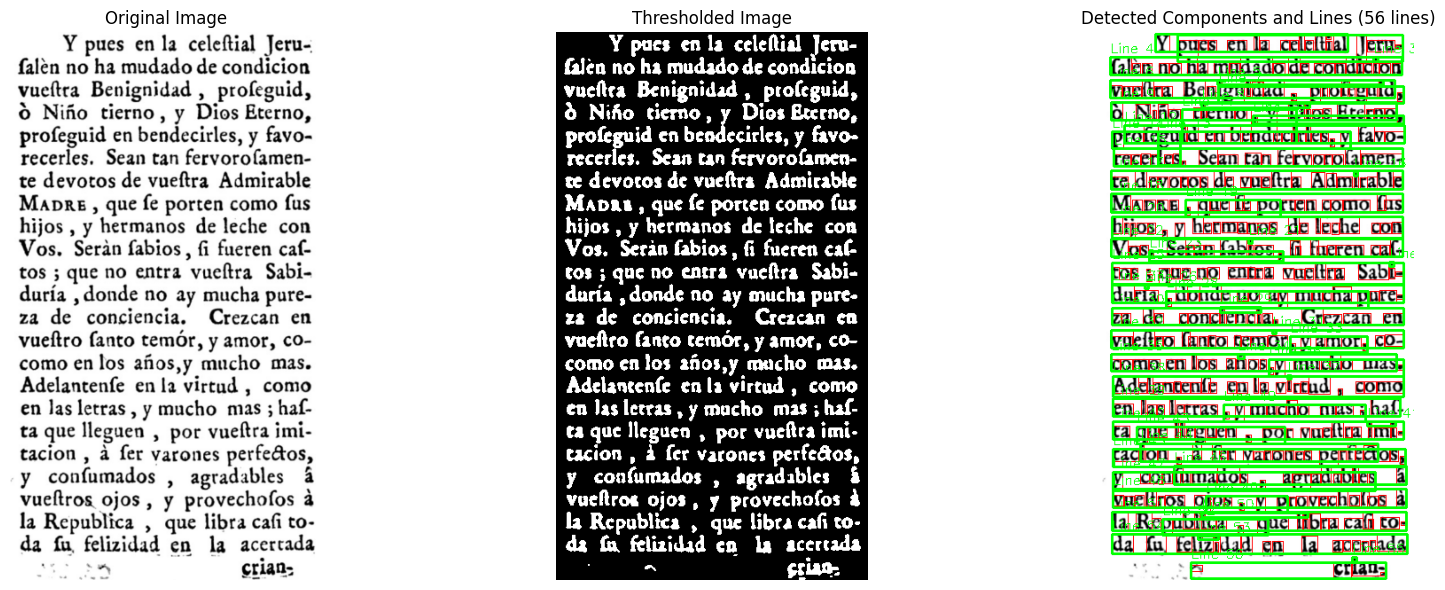

Detected 513 individual text components
Grouped into 56 text lines
Preparing 56 text regions for OCR...
Processing with TrOCR model...
Loading TrOCR model 'qantev/trocr-large-spanish' on cuda...
OCR result for region_1: Y pues  en la  celebrial
OCR result for region_2: pues en la  celebrial Jeru-
OCR result for region_3: 
OCR result for region_4: falén no ha mudado de condicion
OCR result for region_5: amidad    «maña»
OCR result for region_6: vueftra  Benignidad,  profeguid
OCR result for region_7: ignidad,  proleguid,
OCR result for region_8: (1,1)
OCR result for region_9: o  Niño  tierno, y  Dios Eterno,
OCR result for region_10: , Y «DIOS CIETNO,
OCR result for region_11: id en bendeci
OCR result for region_12: rofeguid en bendecirles, y favo-
OCR result for region_13: Ies
OCR result for region_14: profeguid en bendecirles, y
OCR result for region_15: recerles.  Sean tan fervorofamen
OCR result for region_16: 
OCR result for region_17: te devotos de vueftra  Admirable
OCR result fo

In [8]:
# Example usage
if __name__ == "__main__":
    image_path = r"C:\Users\prana\Downloads\Screenshot 2025-04-01 210010.png"  # Replace with your image path
    output_dir = "ocr_results"  # Directory to save results
    
    # Run complete OCR pipeline
    _, ocr_results, combined_text = run_complete_ocr_pipeline(
        image_path, 
        output_dir=output_dir, 
        debug=True,
        model_name='qantev/trocr-large-spanish',  # Spanish TrOCR model
        batch_size=4
    )
    
    print("\n==== COMBINED RECOGNIZED TEXT ====")
    print(combined_text)

In [9]:
import editdistance
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

In [10]:
def calculate_jaccard_similarity(text1, text2):
    """Calculate Jaccard Similarity between two texts."""
    set1 = set(text1.split())
    set2 = set(text2.split())
    intersection = len(set1.intersection(set2))
    union = len(set1.union(set2))
    return intersection / union if union != 0 else 0.0

In [11]:
def calculate_cer(text1, text2):
    """Calculate Character Error Rate (CER) between two texts."""
    text1 = text1.replace(" ", "").replace("\n", "")
    text2 = text2.replace(" ", "").replace("\n", "")
    
    # Calculate edit distance and CER
    distance = editdistance.eval(text1, text2)
    cer = distance / max(len(text1), len(text2))
    
    return cer

In [12]:
def calculate_wer(text1, text2):
    """Calculate Word Error Rate (WER) between two texts."""
    words1 = text1.split()
    words2 = text2.split()
    
    # Calculate edit distance and WER
    distance = editdistance.eval(words1, words2)
    wer = distance / max(len(words1), len(words2))
    
    return wer

In [13]:
def calculate_cosine_similarity(text1, text2):
    """Calculate Cosine Similarity between two texts."""
    vectorizer = CountVectorizer().fit_transform([text1, text2])
    vectors = vectorizer.toarray()
    cos_sim = np.dot(vectors[0], vectors[1]) / (np.linalg.norm(vectors[0]) * np.linalg.norm(vectors[1]))
    return cos_sim

In [14]:
def calculate_bleu(text1, text2):
    """Calculate BLEU score between two texts."""
    reference = [text2.split()]
    candidate = text1.split()
    smoothing_function = SmoothingFunction().method1
    return sentence_bleu(reference, candidate, smoothing_function=smoothing_function)

In [16]:
# Example usage
text1 = '''
Y pues  en la  celebrial
pues en la  celebrial Jeru-

falén no ha mudado de condicion
amidad    «maña»
vueftra  Benignidad,  profeguid
ignidad,  proleguid,
(1,1)
o  Niño  tierno, y  Dios Eterno,
, Y «DIOS CIETNO,
id en bendeci
rofeguid en bendecirles, y favo-
Ies
profeguid en bendecirles, y
recerles.  Sean tan fervorofamen

te devotos de vueftra  Admirable
MADRE, que le porten como fus
, que le por
hijos, y hermanos de leche  con

Vos.  Serán fabios, fi fueren caf-
.  Seran labios y

tos ; que no entra vueltra  Sabi-

duría, donde no ay mucha pure-
, donde no ay mucha p
"an a"
za de  conciencia.   Crezcan en

vueftro lanto temór, y amor, co-
, y amor,

como en los años, y mucho  más
,y mucho  más.

Adelantente en la virtud,  como
en las letras, y mucho  más ; haf-
, y mucho  más ;
.
ta que lleguen,  por vueltra imi-
que lleguen,  por
ion, à  fer varones perfect
tacion, a fer varones perfectos,
fumados,    agradables   à
y  confumados    agradables
vueftros ojos, y provechofos à
jos, y p
“,
la República,  que libra café-
publica,  q
.
da  fu felizidad en  la  acerrada

y    «  » ,   crían:
'''

text2 = '''Y pues en la celestial Jeru- salen no ha mudado de condicion vuestra Benignidad, proseguid, o Niño tierno, y Dios Eterno, proseguid en bendecirles, y favo- recerles. Sean tan fervorosamen- te devotos de vuestra Admirable MADRE, que se porten como sus hijos, y hermanos de leche con Vos. Seran sabios, si fueren cas- tos; que no entra vuestra Sabi- duria, donde no ay mucha pure- za de conciencia. Crezcan en vuestro santo temor, y amor, co- como en los años, y mucho mas. Adelantense en la virtud, como en las letras, y mucho mas; has- ta que lleguen, por vuesetra imi- tacion, a ser varones perfectos, y consumados, agradables a vuestros ojos, y provechosos a la Republica, que libra casi to- da su felizidad en la acertada'''

In [17]:
print(f"CER: {calculate_cer(text1, text2):.4f}")
print(f"WER: {calculate_wer(text1, text2):.4f}")
print(f"Cosine Similarity: {calculate_cosine_similarity(text1, text2):.4f}")
print(f"BLEU Score: {calculate_bleu(text1, text2):.4f}")
print(f"Jaccard Similarity: {calculate_jaccard_similarity(text1, text2):.4f}")

CER: 0.3475
WER: 0.5427
Cosine Similarity: 0.7831
BLEU Score: 0.2497
Jaccard Similarity: 0.4258


In [3]:
!pip install easyocr

   ---------------------------------------- 0.0/2.9 MB ? eta -:--:--
   ---------- ----------------------------- 0.8/2.9 MB 3.7 MB/s eta 0:00:01
   --------------------- ------------------ 1.6/2.9 MB 3.8 MB/s eta 0:00:01
   ------------------------------------ --- 2.6/2.9 MB 4.2 MB/s eta 0:00:01
   ---------------------------------------- 2.9/2.9 MB 4.1 MB/s eta 0:00:00


In [4]:
import cv2
import easyocr
import pytesseract
from jiwer import wer, cer
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
import nltk
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\prana\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.


True

In [5]:
def calculate_metrics(ground_truth, predicted):
    # Calculate error rates
    cer_score = cer(ground_truth, predicted)
    wer_score = wer(ground_truth, predicted)
    
    # Calculate BLEU score
    reference = [ground_truth.split()]
    candidate = predicted.split()
    bleu_score = sentence_bleu(reference, candidate, 
                              smoothing_function=SmoothingFunction().method1)
    
    return {
        'CER': cer_score,
        'WER': wer_score,
        'BLEU': bleu_score
    }

def ocr_comparison(image_path, ground_truth, languages=['es']):
    # Read image
    img = cv2.imread(image_path)
    
    # EasyOCR
    reader = easyocr.Reader(languages)
    easyocr_result = reader.readtext(img, detail=0)
    easyocr_text = ' '.join(easyocr_result)
    
    # Tesseract
    tesseract_text = pytesseract.image_to_string(img, lang='spa')
    
    # Calculate metrics
    easyocr_metrics = calculate_metrics(ground_truth, easyocr_text)
    tesseract_metrics = calculate_metrics(ground_truth, tesseract_text)
    
    return {
        'EasyOCR': easyocr_metrics,
        'Tesseract': tesseract_metrics,
        'EasyOCR_Text': easyocr_text,
        'Tesseract_Text': tesseract_text
    }

In [17]:
import pytesseract
pytesseract.pytesseract.tesseract_cmd = r"C:\Program Files\Tesseract-OCR\tesseract.exe"


In [18]:
# Example usage
image_path = r"C:\Users\prana\Downloads\Screenshot 2025-04-01 210010.png" 
ground_truth = '''Y pues en la celestial Jeru- salen no ha mudado de condicion vuestra Benignidad, proseguid, o Niño tierno, y Dios Eterno, proseguid en bendecirles, y favo- recerles. Sean tan fervorosamen- te devotos de vuestra Admirable MADRE, que se porten como sus hijos, y hermanos de leche con Vos. Seran sabios, si fueren cas- tos; que no entra vuestra Sabi- duria, donde no ay mucha pure- za de conciencia. Crezcan en vuestro santo temor, y amor, co- como en los años, y mucho mas. Adelantense en la virtud, como en las letras, y mucho mas; has- ta que lleguen, por vuesetra imi- tacion, a ser varones perfectos, y consumados, agradables a vuestros ojos, y provechosos a la Republica, que libra casi to- da su felizidad en la acertada'''

results = ocr_comparison(image_path, ground_truth)

print(f"EasyOCR Results:\nCER: {results['EasyOCR']['CER']:.2%}"
      f"\nWER: {results['EasyOCR']['WER']:.2%}"
      f"\nBLEU: {results['EasyOCR']['BLEU']:.4f}\n")

print(f"Tesseract Results:\nCER: {results['Tesseract']['CER']:.2%}"
      f"\nWER: {results['Tesseract']['WER']:.2%}"
      f"\nBLEU: {results['Tesseract']['BLEU']:.4f}")

TesseractError: (1, 'Error opening data file C:\\Program Files\\Tesseract-OCR/tessdata/spa.traineddata Please make sure the TESSDATA_PREFIX environment variable is set to your "tessdata" directory. Failed loading language \'spa\' Tesseract couldn\'t load any languages! Could not initialize tesseract.')